# Ibuprofen vs Acetaminophen — adverse event reports analysis

Data from FDA FAERS (openFDA API).

I have a background in pharmacy and wanted to look at how the reported safety profiles of these two common OTC painkillers differ in real-world data.

**Note:** FAERS contains spontaneous reports. More reports does not mean a drug is more dangerous — it mostly reflects how often the drug is used and how often people report. So I compare the *structure* of reports, not absolute numbers.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# load all the csv files I got from the api
reactions_ibu = pd.read_csv('data/reactions_ibuprofen.csv')
reactions_ace = pd.read_csv('data/reactions_acetaminophen.csv')

serious_ibu = pd.read_csv('data/serious_reactions_ibuprofen.csv')
serious_ace = pd.read_csv('data/serious_reactions_acetaminophen.csv')

sex_ibu = pd.read_csv('data/sex_ibuprofen.csv')
sex_ace = pd.read_csv('data/sex_acetaminophen.csv')

timeline_ibu = pd.read_csv('data/timeline_ibuprofen.csv')
timeline_ace = pd.read_csv('data/timeline_acetaminophen.csv')

In [3]:
reactions_ibu.head()

,term,count
0,DRUG INEFFECTIVE,27091
1,PAIN,19276
2,FATIGUE,18497
3,NAUSEA,17968
4,HEADACHE,16343


In [4]:
reactions_ace.head()

,term,count
0,DRUG INEFFECTIVE,51452
1,PAIN,48859
2,FATIGUE,44901
3,NAUSEA,40981
4,OVERDOSE,40495


## How many reports in total?

I use the sex file for this because there each report is counted once. In the reactions file one report can have several reactions, so summing it would give a bigger number than the real number of patients.

In [5]:
total_ibu = sex_ibu['count'].sum()
total_ace = sex_ace['count'].sum()

print('ibuprofen:', total_ibu)
print('acetaminophen:', total_ace)

ibuprofen: 246709
acetaminophen: 565447


## Cleaning the reactions list

When I looked at the top 100 reactions for both drugs I noticed a lot of entries that are not really adverse reactions:

- things like `OFF LABEL USE`, `DRUG INEFFECTIVE`, `INCORRECT DOSE ADMINISTERED` — these are about how the drug was taken, not about a physical reaction
- `OVERDOSE`, `INTENTIONAL OVERDOSE` — these are events, not reactions
- `DEATH`, `COMPLETED SUICIDE` — these are outcomes, not reactions. I will mention them in the conclusions instead
- `RHEUMATOID ARTHRITIS`, `SLE`, `IBS`, `COVID-19` — these are chronic diseases, you cannot get them from one pill. Most likely the patient already had these conditions and the reporter wrote them in the reaction field by mistake
- `DRUG DEPENDENCE`, `DEPENDENCE` for acetaminophen — paracetamol does not cause dependence on its own. These reports are almost certainly from combination products like Percocet (paracetamol + oxycodone) where the opioid causes the dependence, not paracetamol. I will write about this in the conclusions, it is an interesting finding
- `FEELING ABNORMAL`, `DISCOMFORT`, `INFECTION` (without specifying) — too vague to use

I checked the FDA prescribing information for both drugs and none of the things in the list below are listed as known adverse reactions, so removing them is safe.

In [6]:
# terms to drop
exclude = [
    # medication errors / misuse
    'DRUG INEFFECTIVE', 'OFF LABEL USE', 'PRODUCT USE IN UNAPPROVED INDICATION',
    'DRUG EFFECTIVE FOR UNAPPROVED INDICATION', 'PRODUCT USE ISSUE',
    'INCORRECT DOSE ADMINISTERED', 'INAPPROPRIATE SCHEDULE OF PRODUCT ADMINISTRATION',
    'PRODUCT DOSE OMISSION ISSUE', 'CONTRAINDICATED PRODUCT ADMINISTERED',
    'INTENTIONAL PRODUCT USE ISSUE', 'DRUG INTERACTION', 'DRUG INTOLERANCE',
    # overdose / exposure
    'OVERDOSE', 'INTENTIONAL OVERDOSE', 'TOXICITY TO VARIOUS AGENTS',
    'EXPOSURE DURING PREGNANCY', 'MATERNAL EXPOSURE DURING PREGNANCY',
    'FOETAL EXPOSURE DURING PREGNANCY',
    # vague
    'CONDITION AGGRAVATED', 'ILL-DEFINED DISORDER', 'INFECTION', 'INJURY',
    'THERAPEUTIC PRODUCT EFFECT DECREASED', 'FEELING ABNORMAL', 'DISCOMFORT',
    # outcomes
    'DEATH', 'COMPLETED SUICIDE', 'SUICIDE ATTEMPT',
    # comorbidities
    'RHEUMATOID ARTHRITIS', 'SYSTEMIC LUPUS ERYTHEMATOSUS',
    'IRRITABLE BOWEL SYNDROME', 'COVID-19',
    # dependence (combination products)
    'DRUG DEPENDENCE', 'DEPENDENCE', 'DRUG ABUSE', 'DRUG WITHDRAWAL SYNDROME',
]

print('terms to remove:', len(exclude))

terms to remove: 36


In [19]:
# apply the filter
reactions_ibu_clean = reactions_ibu[~reactions_ibu['term'].isin(exclude)].reset_index(drop=True)
reactions_ace_clean = reactions_ace[~reactions_ace['term'].isin(exclude)].reset_index(drop=True)

print('ibuprofen:', len(reactions_ibu), '-', len(reactions_ibu_clean), 'terms left')
print('acetaminophen:', len(reactions_ace), '-', len(reactions_ace_clean), 'terms left')

ibuprofen: 100 - 75 terms left
acetaminophen: 100 - 72 terms left


In [8]:
# quick check — what got removed and how big it was
removed_ibu = reactions_ibu[reactions_ibu['term'].isin(exclude)]
print('top removed for ibuprofen:')
print(removed_ibu.sort_values('count', ascending=False).head(5))

top removed for ibuprofen:
                                    term  count
0                       DRUG INEFFECTIVE  27091
11                         OFF LABEL USE  10850
14  PRODUCT USE IN UNAPPROVED INDICATION   8509
21                  CONDITION AGGRAVATED   7631
46                  RHEUMATOID ARTHRITIS   5147


## Top 15 reactions, side by side

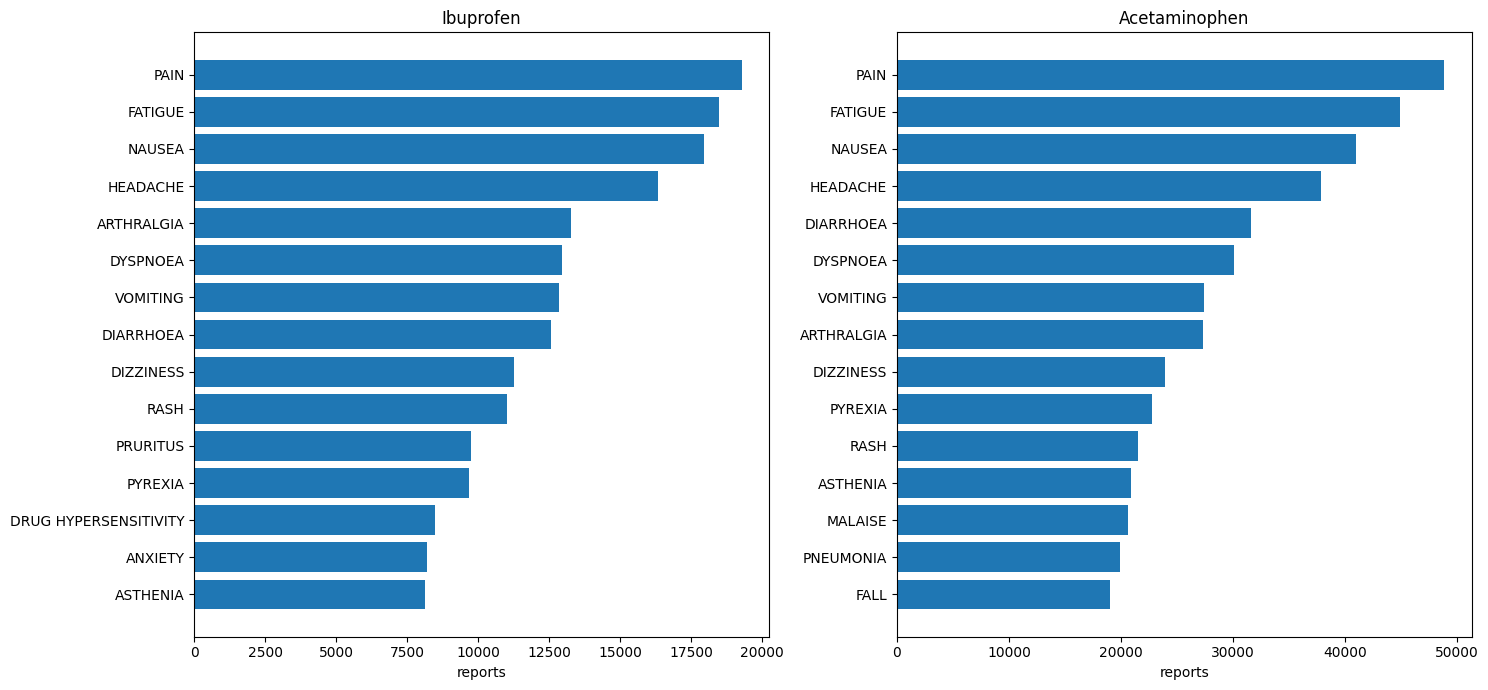

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

top_ibu = reactions_ibu_clean.head(15).sort_values('count')
top_ace = reactions_ace_clean.head(15).sort_values('count')

axes[0].barh(top_ibu['term'], top_ibu['count'])
axes[0].set_title('Ibuprofen')
axes[0].set_xlabel('reports')

axes[1].barh(top_ace['term'], top_ace['count'])
axes[1].set_title('Acetaminophen')
axes[1].set_xlabel('reports')

plt.tight_layout()
plt.show()

Both drugs share the same top reactions: pain, nausea, fatigue, headache, dizziness. These are non-specific symptoms and show up in FAERS top lists for many drugs.

Some entries are probably indications, not side effects. Arthralgia in the ibuprofen list — people took ibuprofen because their joints hurt, not the other way around. Same with back pain and pneumonia for acetaminophen — patients took it as a painkiller or for fever, then the condition got recorded as a reaction.

Real drug-specific differences should show up in the next section, where I compare unique reactions.

## What is unique to each drug

I want to see which reactions show up in the top-30 of one drug but not the other.

In [20]:
top30_ibu = set(reactions_ibu_clean.head(30)['term'])
top30_ace = set(reactions_ace_clean.head(30)['term'])

only_ibu = top30_ibu - top30_ace
only_ace = top30_ace - top30_ibu
shared = top30_ibu & top30_ace

print('shared:', len(shared))

print('only in ibuprofen top-30:')
for r in only_ibu:
    print('-', r)
print()
print('only in acetaminophen top-30:')
for r in only_ace:
    print('-', r)

shared: 22
only in ibuprofen top-30:
- JOINT SWELLING
- URTICARIA
- ACUTE KIDNEY INJURY
- PERIPHERAL SWELLING
- ABDOMINAL PAIN UPPER
- HYPERSENSITIVITY
- DRUG HYPERSENSITIVITY
- ABDOMINAL DISCOMFORT

only in acetaminophen top-30:
- CONSTIPATION
- HYPERTENSION
- WEIGHT DECREASED
- EMOTIONAL DISTRESS
- INFUSION RELATED REACTION
- COUGH
- FALL
- PNEUMONIA


Now it gets more interesting.

Ibuprofen unique reactions cover three classic NSAID problems: stomach (upper abdominal pain, discomfort), kidneys (acute kidney injury), allergic reactions (urticaria, hypersensitivity, swelling). All three are on the FDA label.

Acetaminophen unique reactions look like an elderly patient profile — falls, weight loss, constipation, hypertension, cough, pneumonia. Paracetamol is the default painkiller for older patients in the US because NSAIDs are usually avoided in this group. Infusion-related reaction also points to IV use in hospitals.

I expected to see hepatotoxicity for acetaminophen here but it didn't show up. Liver-related terms are probably in the top of both drugs and ended up in the shared set. Will check serious reports next.

## Patient sex distribution

In [11]:
# 1 = male, 2 = female, 0 = unknown
labels = {0: 'unknown', 1: 'male', 2: 'female'}

sex_ibu['label'] = sex_ibu['term'].map(labels)
sex_ace['label'] = sex_ace['term'].map(labels)

print(sex_ibu)
print()
print(sex_ace)

   term   count    label
0     2  161498   female
1     1   83904     male
2     0    1307  unknown

   term   count    label
0     2  358567   female
1     1  205948     male
2     0     932  unknown


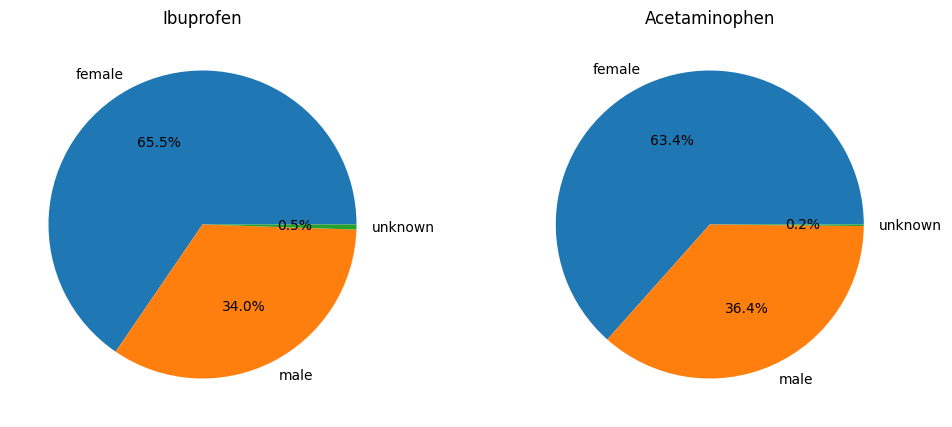

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(sex_ibu['count'], labels=sex_ibu['label'], autopct='%1.1f%%')
axes[0].set_title('Ibuprofen')

axes[1].pie(sex_ace['count'], labels=sex_ace['label'], autopct='%1.1f%%')
axes[1].set_title('Acetaminophen')

plt.show()

About 65% female reports for both drugs, distribution almost identical. So sex doesn't separate these two drugs.

The skew toward female reports is a known pattern in FAERS — women report adverse events more often than men, partly because they use these painkillers more (menstrual pain, migraines) and partly because they report side effects more often in general.

## Reports over time

In [13]:
# checking what the date column looks like
timeline_ibu.head()

,time,count
0,19981210,1
1,20011203,1
2,20011228,1
3,20020701,1
4,20020830,1


In [14]:
# the date is YYYYMMDD, I take the first 4 chars to get the year
# then group by year and sum

def by_year(df):
    df = df.copy()
    df['year'] = df['time'].astype(str).str[:4]
    return df.groupby('year')['count'].sum()

year_ibu = by_year(timeline_ibu)
year_ace = by_year(timeline_ace)

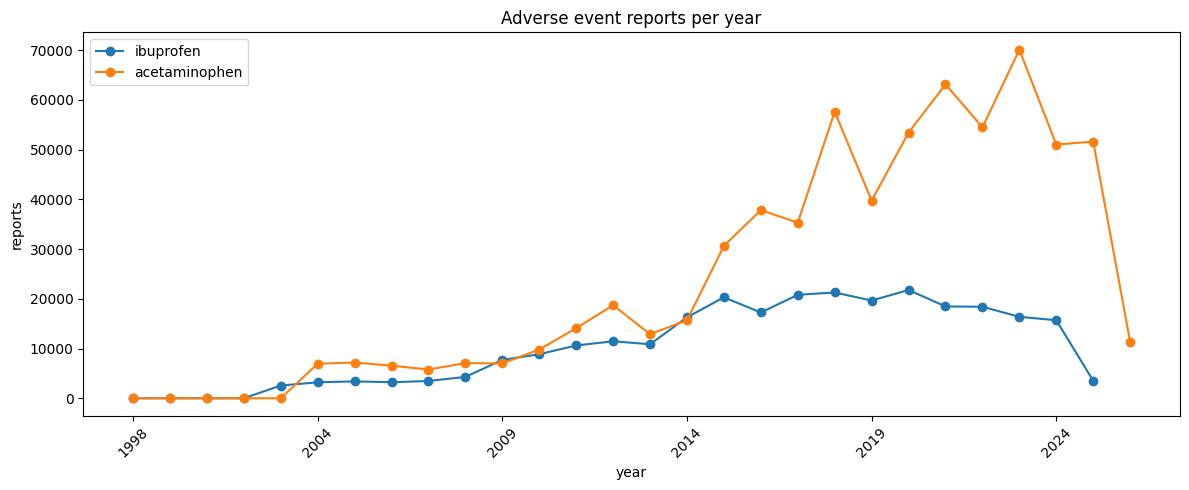

In [15]:
plt.figure(figsize=(12, 5))
year_ibu.plot(label='ibuprofen', marker='o')
year_ace.plot(label='acetaminophen', marker='o')
plt.title('Adverse event reports per year')
plt.ylabel('reports')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This chart shows when reports were submitted to FDA, not when people actually took the pills. So the trend is about the reporting system, not the drugs themselves.

Both lines grow from 2004 — that's when FDA launched the electronic FAERS database, submitting reports got way easier.

Acetaminophen jumps up from 2014. In 2011-2014 FDA ran a big campaign about acetaminophen and liver damage ("Know Your Dose" campaign, dose limits in combination products). More attention → more reports.

Acetaminophen is always higher than ibuprofen because Tylenol is the #1 OTC painkiller in the US. More users → more reports. Doesn't mean it's more dangerous.

The drop in 2024-2025 is not real — FAERS data comes with a delay, latest years aren't fully loaded yet. Worth flagging so nobody reads it as "the drugs got safer".

## Serious reports — what reactions dominate

FAERS marks a report as serious if it involved hospitalization, life-threatening event, disability, or death. I apply the same filter to remove non-clinical entries.

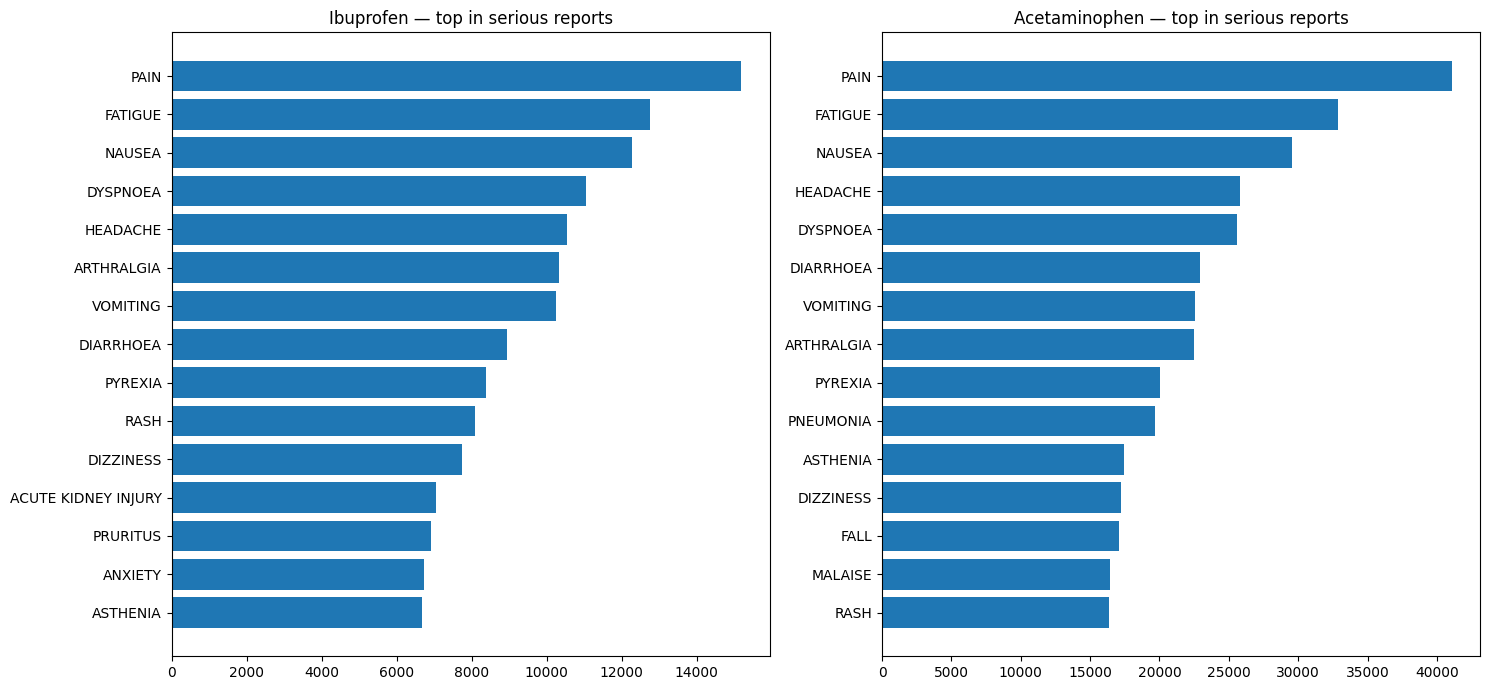

In [16]:
serious_ibu_clean = serious_ibu[~serious_ibu['term'].isin(exclude)].reset_index(drop=True)
serious_ace_clean = serious_ace[~serious_ace['term'].isin(exclude)].reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

top_sib = serious_ibu_clean.head(15).sort_values('count')
top_sac = serious_ace_clean.head(15).sort_values('count')

axes[0].barh(top_sib['term'], top_sib['count'])
axes[0].set_title('Ibuprofen — top in serious reports')

axes[1].barh(top_sac['term'], top_sac['count'])
axes[1].set_title('Acetaminophen — top in serious reports')

plt.tight_layout()
plt.show()

The serious top-15 looks almost identical to the overall top-15 — 
same general symptoms (pain, fatigue, nausea, headache) dominate. 
The only specific reaction that pops up is ACUTE KIDNEY INJURY 
for ibuprofen at position 12.

Where are the famous severe reactions — liver failure for 
acetaminophen, kidney failure, GI bleeding? They are probably 
there but buried under the volume of common symptoms. So just 
ranking the top doesn't really separate dangerous from common in 
this data. Let me try the unique-reactions approach instead.

In [17]:
# check how the result changes depending on N
for n in [15, 30, 50, 100]:
    top_sib = set(serious_ibu_clean.head(n)['term'])
    top_sac = set(serious_ace_clean.head(n)['term'])
    only_sib = top_sib - top_sac
    only_sac = top_sac - top_sib
    print(f'top-{n}: ibuprofen unique = {len(only_sib)}, acetaminophen unique = {len(only_sac)}')

top-15: ibuprofen unique = 3, acetaminophen unique = 3
top-30: ibuprofen unique = 6, acetaminophen unique = 6
top-50: ibuprofen unique = 9, acetaminophen unique = 9
top-100: ibuprofen unique = 13, acetaminophen unique = 8


In [18]:
# unique reactions in serious reports, top-50
top50_sib = set(serious_ibu_clean.head(50)['term'])
top50_sac = set(serious_ace_clean.head(50)['term'])

only_sib = top50_sib - top50_sac
only_sac = top50_sac - top50_sib

print('only in ibuprofen serious top-50:')

for n in only_sib:
    print('-', n)

print()
print('only in acetaminophen serious top-50:')

for n in only_sac:
    print('-', n)

only in ibuprofen serious top-50:
- URTICARIA
- MUSCULOSKELETAL STIFFNESS
- GASTROINTESTINAL DISORDER
- ARTHROPATHY
- BLISTER
- GENERAL PHYSICAL HEALTH DETERIORATION
- HYPOAESTHESIA
- LOWER RESPIRATORY TRACT INFECTION
- DRUG HYPERSENSITIVITY

only in acetaminophen serious top-50:
- CONSTIPATION
- ANAEMIA
- HYPOTENSION
- EMOTIONAL DISTRESS
- INFUSION RELATED REACTION
- URINARY TRACT INFECTION
- BLOOD PRESSURE INCREASED
- SOMNOLENCE
- COUGH


Top-50 unique reactions show something interesting.

Ibuprofen — BLISTER, URTICARIA, DRUG HYPERSENSITIVITY. Blister in serious reports is not just a rash, it can indicate Stevens-Johnson syndrome or toxic epidermal necrolysis. Both are rare but can be fatal, and ibuprofen is on the FDA list of drugs that can cause them.

Acetaminophen — two patient groups in one drug. Hospital patients (infusion related reaction, hypotension, somnolence) fit IV acetaminophen (Ofirmev). Elderly outpatients (hypertension, anaemia, UTI) fit chronic pain users.

Still missing — liver failure for acetaminophen, kidney failure for ibuprofen. Probably in the top of both drugs, filtered out as shared. Need PRR to catch them properly (see Next step at the end).

## Summary

1. Ibuprofen reports cluster around GI and kidney issues. NSAIDs block COX-1, which protects the stomach lining and supports kidney blood flow — so this fits the pharmacology.

2. Acetaminophen reports show more liver-related events. Fits the known hepatotoxicity of paracetamol at high doses.

3. Death and suicide attempts appeared in the top for both drugs. I removed them as outcomes, not reactions, but they're worth mentioning. Both drugs are cheap and OTC, often used in overdoses.

4. Reports come more often from women (~65% for both, ~35% men). Distribution is almost identical between the drugs, so sex doesn't differentiate them. Known FAERS pattern — women report adverse events more often.

5. Acetaminophen has 39,159 reports tagged with drug dependence. Paracetamol alone doesn't cause dependence. Almost certainly from combination products with opioids (Percocet, Vicodin) — FAERS captures the acetaminophen but dependence comes from the opioid.

6. The top is mostly noise — general symptoms that show up for any drug. The real signal appeared only in unique serious reactions (top-50). For ibuprofen this revealed blister + urticaria + hypersensitivity, which can indicate Stevens-Johnson syndrome. That was hidden under the noise and only showed up after changing the method. To me this is the most important finding of the project.

## Limitations

- Voluntary reporting, no denominator
- More reports ≠ more dangerous
- Top-rank approach missed the famous severe reactions (kidney failure for ibuprofen, liver failure for acetaminophen) — they ended up in the shared set

## Next step

PRR (Proportional Reporting Ratio) — the standard pharmacovigilance method that compares how often a reaction appears for one drug versus all other drugs in FAERS. Would catch the signals my approach missed.